# Advanced Modeling

Tujuan :

Setelah melalui tahap **Baseline Modeling**, **Historical Modeling**, dan **Elo Modeling**, proyek ini telah menghasilkan sekumpulan fitur yang semakin kaya dalam merepresentasikan kondisi masing-masing tim sebelum pertandingan berlangsung. Tahap berikutnya adalah mengevaluasi apakah algoritma yang lebih kompleks mampu memanfaatkan informasi tersebut secara lebih efektif dibandingkan model-model sebelumnya.

Pada notebook ini akan dilakukan eksperimen menggunakan dua algoritma *gradient boosting*, yaitu **XGBoost** dan **LightGBM**. Kedua algoritma dipilih karena dikenal memiliki performa yang baik pada berbagai permasalahan klasifikasi serta mampu menangkap hubungan non-linear antar fitur yang mungkin tidak dapat direpresentasikan secara optimal oleh model yang lebih sederhana. Agar hasil eksperimen dapat dibandingkan secara adil, seluruh konfigurasi utama akan dipertahankan sama dengan notebook pemodelan sebelumnya. Dataset yang digunakan tetap berasal dari hasil **Elo Feature Engineering**, proses pemisahan data tetap menggunakan **time-based train-test split**, dan seluruh preprocessing tetap dilakukan melalui **Pipeline** untuk menghindari *data leakage*.

Pada akhir notebook ini akan dilakukan perbandingan menyeluruh terhadap seluruh eksperimen pemodelan yang telah dilakukan, sehingga dapat ditentukan model terbaik yang akan digunakan sebagai dasar pembangunan **Match Prediction API** pada tahap berikutnya.

## 1. Load Elo Dataset

Memuat dataset hasil Elo Rating Engine yang akan digunakan sebagai dasar seluruh eksperimen Advanced Modeling. Karena kita ingin membandingkan algoritma, dataset yang dipakai harus sama dengan notebook sebelumnya.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/elo_features.csv")

In [3]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_last5_winrate,away_last5_winrate,home_last10_winrate,...,away_avg_goals_scored,home_avg_goals_conceded,away_avg_goals_conceded,home_goal_difference_form,away_goal_difference_form,match_result,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,D,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,H,1500.000000,1500.000000,1510.000000,1490.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,0.000000,0.500000,0.000000,...,2.000000,2.000000,1.000000,-1.000000,1.000000,H,1490.000000,1510.000000,1500.575011,1499.424989
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,0.333333,0.333333,0.333333,...,1.333333,1.333333,1.666667,0.333333,-0.333333,D,1499.424989,1500.575011,1499.458089,1500.541911
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,0.250000,0.250000,0.250000,...,1.750000,1.750000,1.500000,-0.250000,0.250000,H,1500.541911,1499.458089,1510.510716,1489.489284


In [4]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_last5_winrate,away_last5_winrate,home_last10_winrate,...,away_avg_goals_scored,home_avg_goals_conceded,away_avg_goals_conceded,home_goal_difference_form,away_goal_difference_form,match_result,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,D,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,H,1500.000000,1500.000000,1510.000000,1490.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,0.000000,0.500000,0.000000,...,2.000000,2.000000,1.000000,-1.000000,1.000000,H,1490.000000,1510.000000,1500.575011,1499.424989
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,0.333333,0.333333,0.333333,...,1.333333,1.333333,1.666667,0.333333,-0.333333,D,1499.424989,1500.575011,1499.458089,1500.541911
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,0.250000,0.250000,0.250000,...,1.750000,1.750000,1.500000,-0.250000,0.250000,H,1500.541911,1499.458089,1510.510716,1489.489284


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49433 entries, 0 to 49432
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       49433 non-null  str    
 1   home_team                  49433 non-null  str    
 2   away_team                  49433 non-null  str    
 3   home_score                 49433 non-null  float64
 4   away_score                 49433 non-null  float64
 5   tournament                 49433 non-null  str    
 6   neutral                    49433 non-null  bool   
 7   home_last5_winrate         49292 non-null  float64
 8   away_last5_winrate         49238 non-null  float64
 9   home_last10_winrate        49292 non-null  float64
 10  away_last10_winrate        49238 non-null  float64
 11  home_avg_goals_scored      49292 non-null  float64
 12  away_avg_goals_scored      49238 non-null  float64
 13  home_avg_goals_conceded    49292 non-null  float64
 14  a

Dataset yang digunakan merupakan hasil dari notebook Elo Rating Engine, yang telah menggabungkan tiga kelompok informasi utama:

- Baseline Features
- Historical Features
- Elo Rating

Dengan demikian, eksperimen pada notebook ini tidak lagi berfokus pada pembangunan fitur, melainkan mengevaluasi apakah algoritma Machine Learning yang lebih canggih mampu memanfaatkan informasi tersebut secara lebih efektif dibandingkan Logistic Regression dan Random Forest.

## 2. Feature & Target Separation

Tujuan : 

Memisahkan:

features (X) → informasi yang tersedia sebelum pertandingan
target (y) → hasil pertandingan yang ingin diprediksi

Kita tidak membuat feature baru di sini. Notebook ini khusus Advanced Modeling, jadi dataset hasil Elo Engine digunakan apa adanya.


### 2.1 Membentuk Target

Sama seperti notebook modeling sebelumnya, target match_result dibentuk dari skor pertandingan.

In [6]:
df["match_result"] = df.apply(
    lambda row: (
        "H" if row["home_score"] > row["away_score"]
        else "A" if row["home_score"] < row["away_score"]
        else "D"
    ),
    axis=1
)


In [7]:
df["match_result"].value_counts(normalize=True)

match_result
H    0.490098
A    0.282463
D    0.227439
Name: proportion, dtype: float64

Variabel target match_result dibentuk berdasarkan hasil akhir pertandingan dan terdiri dari tiga kelas, yaitu H (Home Win), D (Draw), dan A (Away Win). Pembentukan target dilakukan sebelum pemisahan fitur agar label yang digunakan tetap konsisten dengan eksperimen Baseline, Historical, dan Elo Modeling.

### 2.2 Menentukan Feature Columns

In [8]:
# CATEGORICAL
categorical_features = [
    "home_team",
    "away_team",
    "tournament"
]

# BOOLEAN
boolean_features = [
    "neutral"
]

# HISTORICAL
historical_features = [
    "home_last5_winrate",
    "home_last10_winrate",
    "home_avg_goals_scored",
    "home_avg_goals_conceded",
    "home_goal_difference_form",
    "away_last5_winrate",
    "away_last10_winrate",
    "away_avg_goals_scored",
    "away_avg_goals_conceded",
    "away_goal_difference_form"
]

# ELO
elo_features = [
    "home_elo_before",
    "away_elo_before"
]

# ALL
feature_columns = (
    categorical_features
    + boolean_features
    + historical_features
    + elo_features
)

### 2.3 Separation

In [9]:
X = df[feature_columns]
y = df["match_result"]

In [10]:
X.head()

,home_team,away_team,tournament,neutral,home_last5_winrate,home_last10_winrate,home_avg_goals_scored,home_avg_goals_conceded,home_goal_difference_form,away_last5_winrate,away_last10_winrate,away_avg_goals_scored,away_avg_goals_conceded,away_goal_difference_form,home_elo_before,away_elo_before
0,Scotland,England,Friendly,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000
1,England,Scotland,Friendly,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1500.000000,1500.000000
2,Scotland,England,Friendly,False,0.000000,0.000000,1.000000,2.000000,-1.000000,0.500000,0.500000,2.000000,1.000000,1.000000,1490.000000,1510.000000
3,England,Scotland,Friendly,False,0.333333,0.333333,1.666667,1.333333,0.333333,0.333333,0.333333,1.333333,1.666667,-0.333333,1499.424989,1500.575011
4,Scotland,England,Friendly,False,0.250000,0.250000,1.500000,1.750000,-0.250000,0.250000,0.250000,1.750000,1.500000,0.250000,1500.541911,1499.458089


In [11]:
y.head()

0    D
1    H
2    H
3    D
4    H
Name: match_result, dtype: str

### 2.4 Feature Leakage Check

In [12]:
forbidden_columns = [
    "home_score",
    "away_score",
    "match_result",
    "home_elo_after",
    "away_elo_after"
]

leakage_columns = [
    col for col in forbidden_columns
    if col in X.columns
]

leakage_columns

[]

Sebelum memasuki tahap pemodelan, dilakukan pemeriksaan terhadap kolom yang berpotensi menyebabkan target leakage. Kolom skor akhir, target pertandingan, serta Elo setelah pertandingan tidak digunakan sebagai fitur karena nilainya baru tersedia setelah pertandingan berlangsung. Hasil pemeriksaan menunjukkan bahwa tidak terdapat kolom yang berpotensi menyebabkan data leakage pada feature set.

### 2.5 Feature Set Final

In [13]:
print("Categorical Features:")
print(categorical_features)

print("\nBoolean Features:")
print(boolean_features)

print("\nHistorical Features:")
print(historical_features)

print("\nElo Features:")
print(elo_features)

print(f"\nTotal Features: {len(feature_columns)}")

Categorical Features:
['home_team', 'away_team', 'tournament']

Boolean Features:
['neutral']

Historical Features:
['home_last5_winrate', 'home_last10_winrate', 'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_goal_difference_form', 'away_last5_winrate', 'away_last10_winrate', 'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_goal_difference_form']

Elo Features:
['home_elo_before', 'away_elo_before']

Total Features: 16


## 3. Time-based Train-Test Split

Membagi dataset berdasarkan urutan waktu menjadi:

80% → Training

20% → Testing

Tanpa melakukan randomization.

### 3.1 Pastikan Dataset Terurut

In [14]:
df["date"].is_monotonic_increasing

True

### 3.2 Tentukan Split Point

In [15]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### 3.3 Validasi Ukuran Dataset

In [16]:
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("Train ratio:", len(X_train) / len(X))
print("Test ratio :", len(X_test) / len(X))

Training samples: 39546
Testing samples : 9887
Train ratio: 0.7999919082394352
Test ratio : 0.2000080917605648


### 3.4 Validasi Rentang Waktu

In [17]:
train_dates = df["date"].iloc[:split_index]
test_dates = df["date"].iloc[split_index:]

print("Training period:")
print(train_dates.min(), "→", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "→", test_dates.max())

Training period:
1872-11-30 → 2016-03-25

Testing period:
2016-03-25 → 2026-06-18


In [18]:
train_dates.max() <= test_dates.min()

True

### 3.5 Cek Distribusi Target

In [19]:
print("=== TRAIN ===")
print(y_train.value_counts(normalize=True))

print("\n=== TEST ===")
print(y_test.value_counts(normalize=True))

=== TRAIN ===
match_result
H    0.493451
A    0.280509
D    0.226041
Name: proportion, dtype: float64

=== TEST ===
match_result
H    0.476687
A    0.290280
D    0.233033
Name: proportion, dtype: float64


Dataset dibagi menggunakan time-based split dengan proporsi 80% data awal sebagai training set dan 20% data terbaru sebagai testing set. Pendekatan ini mempertahankan urutan kronologis pertandingan dan mensimulasikan skenario prediksi dunia nyata, di mana model hanya memiliki akses terhadap pertandingan yang telah terjadi sebelum periode prediksi.

Skema pembagian ini dipertahankan konsisten dengan Baseline, Historical, dan Elo Modeling sehingga hasil Advanced Modeling dapat dibandingkan secara adil dengan eksperimen sebelumnya.

## 4. Advanced Modeling

### 4.1 Feature Types

Sebelum membuat model, kita definisikan lagi tipe fitur agar preprocessing jelas.

In [20]:
categorical_features = [
    "home_team",
    "away_team",
    "tournament"
]

numeric_features = [
    "neutral",

    "home_last5_winrate",
    "home_last10_winrate",
    "home_avg_goals_scored",
    "home_avg_goals_conceded",
    "home_goal_difference_form",

    "away_last5_winrate",
    "away_last10_winrate",
    "away_avg_goals_scored",
    "away_avg_goals_conceded",
    "away_goal_difference_form",

    "home_elo_before",
    "away_elo_before"
]

### 4.2 Modeling Pipeline

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [22]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

### 4.3 XGBoost

#### 4.3.1 XGBoost Modeling

In [23]:
from xgboost import XGBClassifier

In [24]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss"
)

In [25]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

In [26]:
xgb_pipeline.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [27]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [28]:
y_pred_xgb_label = label_encoder.inverse_transform(y_pred_xgb)

### 4.3.2 Evaluasi Awal XGBoost


In [29]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb_label
)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.5918883382219076


In [30]:
print(
    classification_report(
        y_test,
        y_pred_xgb_label
    )
)

              precision    recall  f1-score   support

           A       0.57      0.59      0.58      2870
           D       0.35      0.03      0.05      2304
           H       0.61      0.87      0.72      4713

    accuracy                           0.59      9887
   macro avg       0.51      0.50      0.45      9887
weighted avg       0.54      0.59      0.52      9887



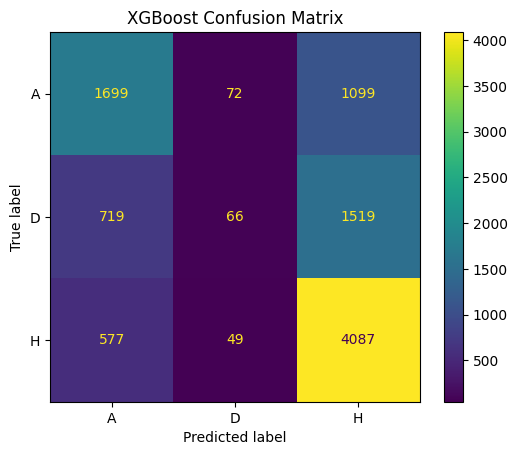

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb_label)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

### 4.4 LightGBM

### 4.4.1 LightGBM Modeling


In [32]:
from lightgbm import LGBMClassifier

In [33]:
lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", lgbm_model)
    ]
)

In [34]:
lgbm_pipeline.fit(
    X_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
y_pred_lgbm = lgbm_pipeline.predict(X_test)

In [36]:
y_pred_lgbm_label = label_encoder.inverse_transform(
    y_pred_lgbm
)

In [37]:
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score

reports_dir = Path("../reports")

advanced_metrics = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb_label),
        "Precision": precision_score(y_test, y_pred_xgb_label, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_xgb_label, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_xgb_label, average="weighted", zero_division=0),
    },
    {
        "Model": "LightGBM",
        "Accuracy": accuracy_score(y_test, y_pred_lgbm_label),
        "Precision": precision_score(y_test, y_pred_lgbm_label, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_lgbm_label, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_lgbm_label, average="weighted", zero_division=0),
    },
])

advanced_metrics.to_csv(reports_dir / "advanced_metrics.csv", index=False)
advanced_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.591888,0.537479,0.591888,0.521782
1,LightGBM,0.591686,0.536832,0.591686,0.523613


#### 4.4.2 Evaluasi Awal LightGBM

In [38]:
accuracy_lgbm = accuracy_score(
    y_test,
    y_pred_lgbm_label
)

print("LightGBM Accuracy:", accuracy_lgbm)

LightGBM Accuracy: 0.59168605239203


In [39]:
print(
    classification_report(
        y_test,
        y_pred_lgbm_label
    )
)

              precision    recall  f1-score   support

           A       0.57      0.59      0.58      2870
           D       0.35      0.03      0.06      2304
           H       0.61      0.87      0.72      4713

    accuracy                           0.59      9887
   macro avg       0.51      0.50      0.45      9887
weighted avg       0.54      0.59      0.52      9887



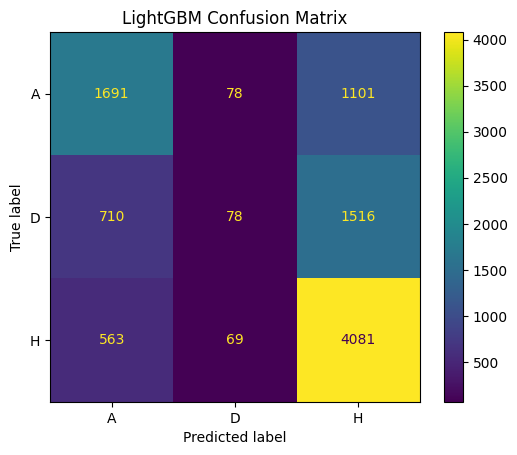

In [40]:
cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm_label
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

### 4.5 Kenapa XGBoost dan LightGBM dibandingkan?

Nah, ini penting untuk markdown notebook.

XGBoost dan LightGBM sama-sama merupakan algoritma gradient boosting berbasis decision tree, tetapi memiliki pendekatan implementasi dan karakteristik optimasi yang berbeda. Keduanya digunakan sebagai kandidat advanced model untuk menguji apakah model non-linear yang lebih kompleks dapat memanfaatkan kombinasi baseline features, historical features, dan Elo Rating secara lebih efektif dibandingkan model sebelumnya.

# 5. Model Evaluation

## 5.1 Advanced Model Evaluation

Hasil evaluasi menunjukkan bahwa kedua model *advanced* memiliki performa yang sangat berdekatan.



In [41]:
import pandas as pd
from pathlib import Path

reports_dir = Path("../reports")
advanced_metrics = pd.read_csv(reports_dir / "advanced_metrics.csv")

advanced_metrics.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,59.19%,53.75%,59.19%,52.18%
1,LightGBM,59.17%,53.68%,59.17%,52.36%



XGBoost memperoleh accuracy sedikit lebih tinggi dibandingkan LightGBM, yaitu **59.19% berbanding 59.17%**. Namun, perbedaannya sangat kecil sehingga secara praktis kedua model menunjukkan performa yang hampir identik.

Menariknya, LightGBM menghasilkan **F1 Score tertinggi di antara kedua advanced model**, meskipun accuracy-nya sedikit lebih rendah. Hal ini menunjukkan bahwa kedua metrik tersebut menangkap aspek performa yang berbeda dan tidak selalu menghasilkan model terbaik yang sama.

---

## 5.2 Perbandingan Seluruh Eksperimen

Untuk melihat perkembangan model secara keseluruhan, hasil eksperimen dari seluruh tahap digabungkan.



In [42]:
baseline_metrics = pd.read_csv(reports_dir / "baseline_metrics.csv")
historical_metrics = pd.read_csv(reports_dir / "historical_metrics.csv")
elo_metrics = pd.read_csv(reports_dir / "elo_metrics.csv")

baseline_metrics["Model"] = baseline_metrics["Model"] + " — Baseline"
historical_metrics["Model"] = historical_metrics["Model"] + " — Historical"
elo_metrics["Model"] = elo_metrics["Model"] + " — Elo"
advanced_metrics_copy = advanced_metrics.copy()
advanced_metrics_copy["Model"] = advanced_metrics_copy["Model"] + " — Elo"

all_metrics = pd.concat([
    baseline_metrics,
    historical_metrics,
    elo_metrics,
    advanced_metrics_copy
], ignore_index=True)

all_metrics.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression — Baseline,57.30%,52.14%,57.30%,50.96%
1,Random Forest — Baseline,50.84%,47.09%,50.84%,47.84%
2,Logistic Regression — Historical,58.05%,52.68%,58.05%,52.09%
3,Random Forest — Historical,54.67%,49.55%,54.67%,47.17%
4,Logistic Regression — Elo,59.32%,55.89%,59.32%,51.28%
5,Random Forest — Elo,57.69%,52.71%,57.69%,50.98%
6,XGBoost — Elo,59.19%,53.75%,59.19%,52.18%
7,LightGBM — Elo,59.17%,53.68%,59.17%,52.36%



---

## 5.3 Perkembangan Model

Jika dibandingkan berdasarkan Logistic Regression sebagai algoritma yang konsisten digunakan sejak awal, terlihat adanya peningkatan bertahap:



In [43]:
perkembangan = pd.DataFrame([
    {"Tahap": "Baseline", "Accuracy": baseline_metrics.loc[0, "Accuracy"], "Perubahan": "—"},
    {"Tahap": "Historical Features", "Accuracy": historical_metrics.loc[0, "Accuracy"], "Perubahan": f"{(historical_metrics.loc[0, 'Accuracy'] - baseline_metrics.loc[0, 'Accuracy']):+.2%}"},
    {"Tahap": "Historical + Elo", "Accuracy": elo_metrics.loc[0, "Accuracy"], "Perubahan": f"{(elo_metrics.loc[0, 'Accuracy'] - historical_metrics.loc[0, 'Accuracy']):+.2%}"}
])

perkembangan.style.format({
    'Accuracy': '{:.2%}'
})

,Tahap,Accuracy,Perubahan
0,Baseline,57.30%,—
1,Historical Features,58.05%,+0.75%
2,Historical + Elo,59.32%,+1.27%



Dengan demikian, peningkatan dari baseline hingga model Logistic Regression dengan Elo mencapai sekitar **2.02 percentage points**.

Hal ini menunjukkan bahwa penambahan informasi historis dan representasi kekuatan tim memberikan kontribusi positif terhadap kemampuan prediksi.

---

## 5.4 Dampak Advanced Modeling

Hasil Advanced Modeling memberikan temuan yang cukup menarik.

Model dengan accuracy tertinggi dari seluruh eksperimen tetap merupakan:

> **Logistic Regression + Historical Features + Elo Rating — 59.32%**

Sementara itu:

```text
XGBoost   → 59.19%
LightGBM  → 59.17%
```

Keduanya sedikit berada di bawah Logistic Regression dengan Elo.

Perbedaannya sangat kecil:

```text
Logistic Regression Elo → 59.32%
XGBoost                 → 59.19%
LightGBM                → 59.17%
```

Dengan demikian, penggunaan algoritma yang lebih kompleks **belum memberikan peningkatan accuracy** pada eksperimen ini.

Temuan tersebut penting karena menunjukkan bahwa model yang lebih kompleks tidak selalu menghasilkan performa yang lebih baik. Dalam dataset ini, representasi informasi melalui fitur yang tersedia tampaknya lebih menentukan dibandingkan peningkatan kompleksitas algoritma.

---

## 5.5 Accuracy vs F1 Score

Jika hanya menggunakan accuracy sebagai ukuran keberhasilan, Logistic Regression dengan Elo terlihat sebagai model terbaik.

Namun, ketika melihat F1 Score, hasilnya sedikit berbeda:

```text
Logistic Regression — Elo → 51.28%
XGBoost                 → 52.18%
LightGBM                → 52.36%
```

LightGBM bahkan menghasilkan F1 Score tertinggi dari seluruh eksperimen yang dilakukan.

Hal ini menunjukkan bahwa LightGBM memiliki distribusi prediksi yang sedikit lebih seimbang antar kelas dibandingkan Logistic Regression dengan Elo, meskipun jumlah prediksi yang benar secara keseluruhan sedikit lebih rendah.

Oleh karena itu, pemilihan model tidak dapat dilakukan hanya berdasarkan satu metrik.

---

## 5.6 Draw Prediction

Salah satu temuan yang konsisten sejak Baseline Modeling adalah sulitnya memprediksi pertandingan yang berakhir **Draw**.

Penambahan historical features dan Elo Rating berhasil meningkatkan performa keseluruhan model, tetapi masalah pada kelas Draw tetap muncul.

Bahkan pada Advanced Modeling, peningkatan kompleksitas algoritma tidak secara otomatis menyelesaikan masalah tersebut.

Hal ini memberikan indikasi bahwa masalah utama bukan semata-mata terletak pada kemampuan algoritma dalam menangkap hubungan non-linear, tetapi juga pada **informasi yang tersedia dalam feature set**.

Dengan kata lain:

> Model yang lebih kompleks tidak dapat sepenuhnya menyelesaikan informasi yang belum direpresentasikan oleh fitur.

Pertandingan imbang kemungkinan dipengaruhi oleh faktor-faktor yang belum tersedia dalam dataset saat ini, seperti kondisi tim, kualitas pemain, lineup, cedera, konteks pertandingan, dan faktor pertandingan lainnya.

---

# 5.7 Final Insight

Seluruh rangkaian eksperimen memberikan beberapa temuan utama.

### 1. Feature Engineering memberikan peningkatan yang konsisten

Performa Logistic Regression meningkat secara bertahap:

```text
57.30%
   ↓
58.05%
   ↓
59.32%
```

Peningkatan tersebut diperoleh tanpa mengganti algoritma, melainkan melalui penambahan informasi secara bertahap.

Historical features memberikan peningkatan dari **57.30% menjadi 58.05%**, sedangkan penambahan Elo Rating kembali meningkatkan accuracy menjadi **59.32%**.

Hal ini memperkuat hipotesis bahwa kualitas representasi informasi memiliki peran penting dalam prediksi hasil pertandingan.

---

### 2. Elo memberikan kontribusi terbesar dalam rangkaian feature engineering

Dibandingkan baseline, model Logistic Regression dengan Elo mengalami peningkatan sekitar **2.02 percentage points**.

Hal ini menjadikan Elo Rating sebagai salah satu komponen fitur paling berpengaruh dalam eksperimen sejauh ini.

Elo kemungkinan memberikan informasi yang lebih ringkas mengenai kekuatan relatif kedua tim dibandingkan statistik pertandingan terakhir secara terpisah.

---

### 3. Algoritma yang lebih kompleks tidak otomatis lebih baik

XGBoost dan LightGBM menghasilkan accuracy masing-masing sebesar **59.19% dan 59.17%**, sedikit di bawah Logistic Regression dengan Elo yang mencapai **59.32%**.

Hasil ini menunjukkan bahwa peningkatan kompleksitas model belum memberikan keuntungan yang berarti pada dataset dan feature set saat ini.

Dengan kata lain, proyek ini memberikan contoh nyata bahwa:

> **Better features can matter more than a more complex algorithm.**

---

### 4. Namun Advanced Models memiliki F1 Score yang lebih baik

Walaupun kalah tipis dalam accuracy, XGBoost dan LightGBM menghasilkan F1 Score yang lebih tinggi dibandingkan Logistic Regression dengan Elo.

LightGBM memperoleh F1 Score sebesar **52.36%**, sementara Logistic Regression dengan Elo memperoleh **51.28%**.

Hal ini menunjukkan bahwa terdapat trade-off antara accuracy dan keseimbangan performa antar kelas.

Oleh karena itu, hasil Advanced Modeling tidak dapat disebut sebagai "gagal" hanya karena accuracy sedikit lebih rendah.

---

### 5. Draw tetap menjadi masalah utama

Seluruh eksperimen menunjukkan pola yang sama:

```text
Home Win → relatif mudah dikenali
Away Win → lebih mudah dikenali setelah feature engineering
Draw     → tetap sulit
```

Masalah ini tidak hilang meskipun historical features, Elo Rating, Random Forest, XGBoost, maupun LightGBM telah digunakan.

Temuan tersebut menjadi salah satu insight paling penting dari proyek ini karena menunjukkan keterbatasan feature set saat ini.

---

### 5. Model terbaik bergantung pada metrik yang digunakan

Jika tujuan utama adalah **accuracy**, model terbaik dalam seluruh eksperimen adalah:

> **Logistic Regression + Historical Features + Elo Rating**

dengan accuracy **59.32%**.

Jika fokus diberikan pada **weighted F1 Score**, model terbaik adalah:

> **LightGBM + Historical Features + Elo Rating**

dengan F1 Score **52.36%**.

Dengan demikian, tidak terdapat satu model yang secara mutlak unggul pada seluruh metrik.

---

## 5.8 Kesimpulan Advanced Modeling

Eksperimen Advanced Modeling menunjukkan bahwa penggunaan algoritma yang lebih kompleks belum memberikan peningkatan accuracy dibandingkan Logistic Regression dengan Elo Rating.

Namun, XGBoost dan LightGBM menghasilkan F1 Score yang sedikit lebih tinggi, sehingga keduanya menunjukkan karakteristik prediksi yang lebih seimbang antar kelas.

Secara keseluruhan, hasil proyek sampai tahap ini memberikan sebuah pola yang cukup jelas:

```text
Feature Quality
      ↓
Baseline
      ↓
Historical Features
      ↓
Elo Rating
      ↓
Performance Improvement
```

Sementara itu:

```text
Model Complexity
      ↓
XGBoost / LightGBM
      ↓
Tidak menghasilkan peningkatan
accuracy yang signifikan
```

Temuan ini menunjukkan bahwa peningkatan performa model pada proyek ini lebih banyak diperoleh melalui **peningkatan kualitas informasi yang diberikan kepada model** daripada sekadar menggunakan algoritma yang lebih kompleks.

Dengan demikian, Advanced Modeling menjadi eksperimen penting bukan hanya karena berhasil mencari model dengan performa terbaik, tetapi juga karena menunjukkan **batas manfaat peningkatan kompleksitas algoritma pada feature set yang tersedia**.

Hasil ini menjadi dasar untuk menentukan apakah proyek akan melanjutkan eksperimen melalui optimasi hyperparameter dan feature engineering lanjutan, atau mulai beralih dari eksperimen model menuju tahap implementasi sistem prediksi.
